## Goals¶
Identification of clusters of excellent, good and poor performing students, using K-Means algorithm
Comparision of exam results of the students from each cluster
Visualization of excellent performance cluster characteristics

In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
#from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [191]:
from xgboost import XGBRegressor

In [192]:
df = pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [193]:
df.columns = df.columns.str.strip().str.replace(" ","_")
df.columns= df.columns.str.replace("/","_")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [194]:
# df['full_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
# df['average_score'] = df['full_score'] / 3
# df['average_score']

In [195]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [196]:
X = df.drop(columns='math_score')
Y = df['math_score']


In [197]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [198]:
Y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [200]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns


In [201]:
cat_features

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')

In [202]:
print(f'Unique values are {df.gender.unique()}')
print(f'Unique values are {df.race_ethnicity.unique()}')
print(f'Unique values are {df.gender.unique()}')
print(f'Unique values are {df.gender.unique()}')
print(f'Unique values are {df.gender.unique()}')

Unique values are <StringArray>
['female', 'male']
Length: 2, dtype: str
Unique values are <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Unique values are <StringArray>
['female', 'male']
Length: 2, dtype: str
Unique values are <StringArray>
['female', 'male']
Length: 2, dtype: str
Unique values are <StringArray>
['female', 'male']
Length: 2, dtype: str


In [203]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_tranformer = StandardScaler()
oh_tranformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_tranformer, cat_features),
        ('StandardScaler', numeric_tranformer, num_features)
    ]
)

In [204]:
X = preprocessor.fit_transform(X)


In [205]:
X.shape

(1000, 19)

In [206]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


In [207]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [208]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Lasso": Lasso(),
#     "Ridge": Ridge(),
#     "K-Neighbors Regressor": KNeighborsRegressor(),
#     "Decision Tree": DecisionTreeRegressor(),
#     "Random Forest Regressor": RandomForestRegressor(),
#     "XGBRegressor": XGBRegressor(), 
#     "CatBoosting Regressor": CatBoostRegressor(verbose=False),
#     "AdaBoost Regressor": AdaBoostRegressor()
# }
# model_list = []
# r2_list =[]

# for i in range(len(list(models))):
#     model = list(models.values())[i]
#     model.fit(X_train, Y_train) # Train model

#     # Make predictions
#     y_train_pred = model.predict(X_train)
#     y_test_pred = model.predict(X_test)
    
#     # Evaluate Train and Test dataset
#     model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(Y_train, y_train_pred)

#     model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(Y_test, y_test_pred)

    
#     print(list(models.keys())[i])
#     model_list.append(list(models.keys())[i])
    
#     print('Model performance for Training set')
#     print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
#     print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
#     print("- R2 Score: {:.4f}".format(model_train_r2))

#     print('----------------------------------')
    
#     print('Model performance for Test set')
#     print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
#     print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
#     print("- R2 Score: {:.4f}".format(model_test_r2))
#     r2_list.append(model_test_r2)
    
#     print('='*35)
#     print('\n')

models = {
    "Linear Regression" : LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(),
    "Ada Boost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(Y_train, y_pred_train)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(Y_test, y_pred_test)

    print(f"Model: {name}")
    print("Performance on Test set")
    print(f"RMSE : {model_test_rmse:.4f}")
    print(f"MAE  : {model_test_mae:.4f}")
    print(f"R2   : {model_test_r2:.4f}")
    print("=" * 40)

    model_list.append(name)
    r2_list.append(model_test_r2)


Model: Linear Regression
Performance on Test set
RMSE : 5.3940
MAE  : 4.2148
R2   : 0.8804
Model: Lasso
Performance on Test set
RMSE : 6.5197
MAE  : 5.1579
R2   : 0.8253
Model: Ridge
Performance on Test set
RMSE : 5.3904
MAE  : 4.2111
R2   : 0.8806
Model: K-Neighbors Regressor
Performance on Test set
RMSE : 7.2553
MAE  : 5.6280
R2   : 0.7837
Model: Decision Tree
Performance on Test set
RMSE : 7.8870
MAE  : 6.1650
R2   : 0.7444
Model: Random Forest Regressor
Performance on Test set
RMSE : 5.9913
MAE  : 4.6312
R2   : 0.8525
Model: XGBRegressor
Performance on Test set
RMSE : 6.4733
MAE  : 5.0577
R2   : 0.8278
Learning rate set to 0.039525
0:	learn: 14.5987177	total: 3.31ms	remaining: 3.31s
1:	learn: 14.2251886	total: 3.59ms	remaining: 1.79s
2:	learn: 13.8866124	total: 3.88ms	remaining: 1.29s
3:	learn: 13.5235688	total: 4.28ms	remaining: 1.06s
4:	learn: 13.1887021	total: 4.56ms	remaining: 908ms
5:	learn: 12.9124226	total: 4.81ms	remaining: 798ms
6:	learn: 12.6000335	total: 5.4ms	remaining:

In [209]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.852486
7,CatBoosting Regressor,0.851632
8,Ada Boost Regressor,0.846106
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783681
4,Decision Tree,0.744368


In [ ]:
#Linear Model we can take
lin_model = LinearRegression()
lin_model = lin_model.fit(X_train, Y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(Y_test, y_pred)*100

print(score)

88.04332983749565


<Axes: xlabel='math_score'>

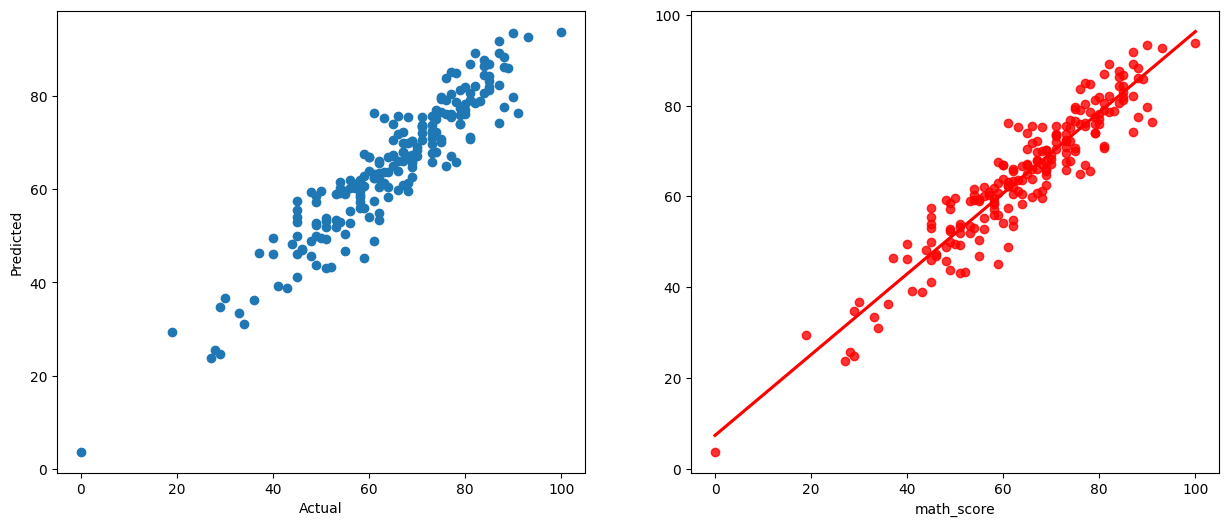

In [214]:
plt.figure(figsize=(15,6))
plt.subplot(121)
plt.scatter(Y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.subplot(122)
sns.regplot(x=Y_test,y=y_pred,ci=None,color ='red')


In [ ]:
y_pred_df = pd.DataFrame({'Actual Value':Y_test, 'Predicted Value': y_pred, 'Differance is': Y_test - y_pred})
y_pred_df

,Actual Value,Predicted Value,Differance is
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
